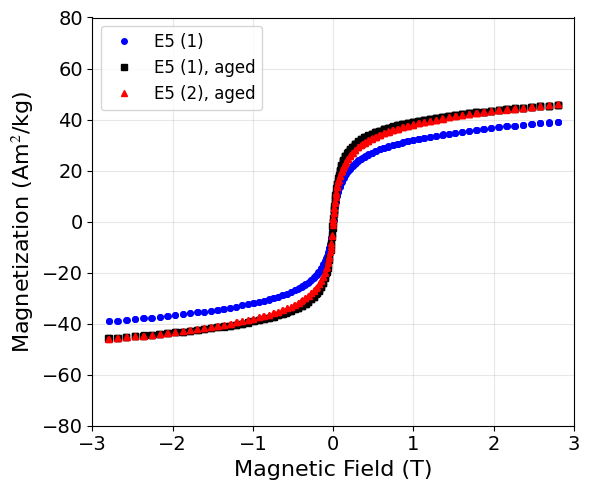

In [8]:
# Standalone experimental M-H plotting script
# Reads VersaLab-style CSV files in the same Excel layout used before
# and plots mass-normalized magnetization vs magnetic field as points only.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Inputs
# ============================================================
MH_DIR = Path(
    r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data"
)

OUT_DIR = MH_DIR

# Selected M-B files (same style as your original script)
MH_FILES = [
    r"FeO_250408_MvsH_300K_2.csv",
    r"FeO_250408_MvsH_300K_3_260414.csv",
    r"FeO_250408_S2_MvsH.csv",
    #r"E1_M-B.csv",
    #r"E2_M-B.csv",
    #r"E3_M-B.csv",
    #r"E4_M-B.csv",
    #r"E5_M-B.csv",
]

# Masses in grams, 1:1 with MH_FILES
MASSES_G = [
    0.0011,
    0.0011,
    0.0253,
    #0.0015,
    #0.0021,
    #0.0033,
    #0.0033,
    #0.0011,
]

# Labels for legend
LEGEND_LABELS = [
    "E5 (1)",
    "E5 (1), aged",
    "E5 (2), aged"
    #"E1",
    #"E2",
    #"E3",
    #"E4",
    #"E5",
]

# Colors
COLORS_MH = ["b", "k", "r", "m", "darkorange"]

# Marker shapes for each sample
MARKERS_MH = ["o", "s", "^", "v", "P"]


# Marker sizes for each sample
MARKER_SIZES_MH = [4, 4, 4, 4, 4]

# ============================================================
# VersaLab CSV format
# row 36 in Excel -> zero-based row 35
# column D -> index 3 = field (Oe)
# column E -> index 4 = moment (emu)
# ============================================================
MH_START_ROW = 35
MH_COL_FIELD = 3
MH_COL_MOM   = 4

# ============================================================
# Plot style
# ============================================================
FONTS = dict(ax=16, tick=14, legend=12, title=16)
FIGSIZE_MH = (6, 5)

# Axis limits; set to None to autoscale
X_LIMS = (-3, 3)
Y_LIMS = (-80, 80)

SAVE_FIG = False
SAVE_NAME = "experimental_MB_overlay_points.png"
DPI = 300

# ============================================================
# Load experimental M-B data
# ============================================================
def load_mh_csv_full(path, mass_g, start_row=MH_START_ROW,
                     col_field=MH_COL_FIELD, col_moment=MH_COL_MOM):
    """
    Read VersaLab-style CSV:
      - field in Oe from column D
      - magnetic moment in emu from column E
      - data starts at row 36 in Excel (zero-based row 35)

    Returns:
      B_T : magnetic field in Tesla
      M   : magnetization in Am^2/kg
    """
    df = pd.read_csv(path, header=None)

    sub = df.iloc[start_row:, [col_field, col_moment]].copy()
    sub.columns = ["H_Oe", "m_emu"]

    B_T = sub["H_Oe"].to_numpy(dtype=float) * 1e-4
    M = sub["m_emu"].to_numpy(dtype=float) / float(mass_g)

    mask = np.isfinite(B_T) & np.isfinite(M)
    return B_T[mask], M[mask]


def _label_from_list(lst, idx, fallback):
    try:
        s = lst[idx]
        return s if isinstance(s, str) and len(s) > 0 else fallback
    except Exception:
        return fallback


def plot_selected_mh():
    assert len(MH_FILES) == len(MASSES_G), "MH_FILES and MASSES_G must have the same length."
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=FIGSIZE_MH)

    for i, (mh_name, mass_g) in enumerate(zip(MH_FILES, MASSES_G)):
        mh_path = MH_DIR / mh_name
        if not mh_path.exists():
            raise FileNotFoundError(f"Missing M-B file: {mh_path}")

        B_true, M_true = load_mh_csv_full(mh_path, mass_g)

        label = _label_from_list(LEGEND_LABELS, i, Path(mh_name).stem)
        color = COLORS_MH[i % len(COLORS_MH)]
        marker = MARKERS_MH[i % len(MARKERS_MH)]
        ms = MARKER_SIZES_MH[i % len(MARKER_SIZES_MH)]

        plt.plot(
            B_true, M_true,
            linestyle='none',
            marker=marker,
            ms=ms,
            color=color,
            label=label
        )

    plt.xlabel("Magnetic Field (T)", fontsize=FONTS["ax"])
    plt.ylabel("Magnetization (Am$^2$/kg)", fontsize=FONTS["ax"])

    if X_LIMS is not None:
        plt.xlim(*X_LIMS)
    if Y_LIMS is not None:
        plt.ylim(*Y_LIMS)

    plt.grid(alpha=0.3)
    plt.legend(fontsize=FONTS["legend"])
    plt.tick_params(labelsize=FONTS["tick"])
    plt.tight_layout()

    if SAVE_FIG:
        plt.savefig(OUT_DIR / SAVE_NAME, dpi=DPI, bbox_inches="tight")

    plt.show()


if __name__ == "__main__":
    plot_selected_mh()

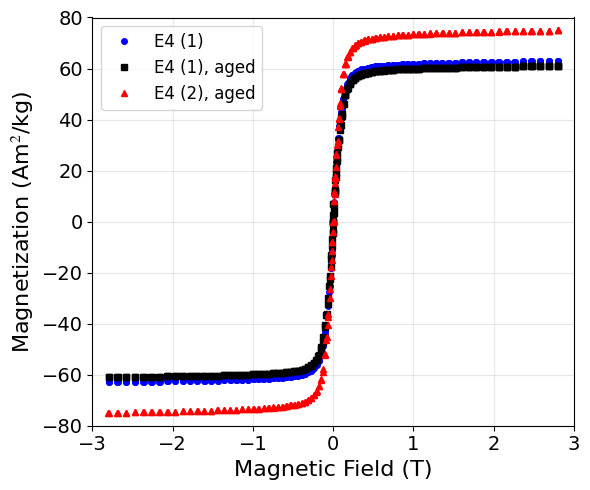

In [21]:
# Standalone experimental M-H plotting script
# Reads VersaLab-style CSV files in the same Excel layout used before
# and plots mass-normalized magnetization vs magnetic field as points only.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Inputs
# ============================================================
MH_DIR = Path(
    r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names"
)

OUT_DIR = MH_DIR

# Selected M-B files (same style as your original script)
MH_FILES = [
    #r"MF-5_S2_MvsH_300K_1.csv",
    #r"MF-5_S2_MvsH_300K_2_260414.csv",
    #r"MF-5_S3_MvsH_300K_1_dired_from_washed_stock_made_260512.csv",
    #r"E1_M-B.csv",
    #r"E2_M-B.csv",
    #r"E3_M-B.csv",
    r"E4_M-B.csv",
    #r"E5_M-B.csv",
    r"E4_measured_again_260520_MvsH_300K_2.csv",
    r"E4_S2_prepared_260519_MvsH_300K_1.csv",
]

# Masses in grams, 1:1 with MH_FILES
MASSES_G = [
    0.0033,
    0.0033,
    0.0050,
    #0.007,
    #0.0011,
    #0.0011,
    #0.0253,
    #0.0015,
    #0.0021,
    #0.0033,
    #0.0033,
    #0.0011,
]

# Labels for legend
LEGEND_LABELS = [
    #"E3 (1)",
    #"E3 (1), aged",
    #"E3 (2), aged",
    "E4 (1)",
    "E4 (1), aged",
    "E4 (2), aged",
    #"E1",
    #"E2",
    #"E3",
    #"E4",
    #"E5",
]

# Colors
COLORS_MH = ["b", "k", "r", "m", "darkorange"]

# Marker shapes for each sample
MARKERS_MH = ["o", "s", "^", "v", "P"]


# Marker sizes for each sample
MARKER_SIZES_MH = [4, 4, 4, 4, 4]

# ============================================================
# VersaLab CSV format
# row 36 in Excel -> zero-based row 35
# column D -> index 3 = field (Oe)
# column E -> index 4 = moment (emu)
# ============================================================
MH_START_ROW = 35
MH_COL_FIELD = 3
MH_COL_MOM   = 4

# ============================================================
# Plot style
# ============================================================
FONTS = dict(ax=16, tick=14, legend=12, title=16)
FIGSIZE_MH = (6, 5)

# Axis limits; set to None to autoscale
X_LIMS = (-3, 3)
Y_LIMS = (-80, 80)

SAVE_FIG = False
SAVE_NAME = "experimental_MB_overlay_points.png"
DPI = 300

# ============================================================
# Load experimental M-B data
# ============================================================
def load_mh_csv_full(path, mass_g, start_row=MH_START_ROW,
                     col_field=MH_COL_FIELD, col_moment=MH_COL_MOM):
    """
    Read VersaLab-style CSV:
      - field in Oe from column D
      - magnetic moment in emu from column E
      - data starts at row 36 in Excel (zero-based row 35)

    Returns:
      B_T : magnetic field in Tesla
      M   : magnetization in Am^2/kg
    """
    df = pd.read_csv(path, header=None)

    sub = df.iloc[start_row:, [col_field, col_moment]].copy()
    sub.columns = ["H_Oe", "m_emu"]

    B_T = sub["H_Oe"].to_numpy(dtype=float) * 1e-4
    M = sub["m_emu"].to_numpy(dtype=float) / float(mass_g)

    mask = np.isfinite(B_T) & np.isfinite(M)
    return B_T[mask], M[mask]


def _label_from_list(lst, idx, fallback):
    try:
        s = lst[idx]
        return s if isinstance(s, str) and len(s) > 0 else fallback
    except Exception:
        return fallback


def plot_selected_mh():
    assert len(MH_FILES) == len(MASSES_G), "MH_FILES and MASSES_G must have the same length."
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=FIGSIZE_MH)

    for i, (mh_name, mass_g) in enumerate(zip(MH_FILES, MASSES_G)):
        mh_path = MH_DIR / mh_name
        if not mh_path.exists():
            raise FileNotFoundError(f"Missing M-B file: {mh_path}")

        B_true, M_true = load_mh_csv_full(mh_path, mass_g)

        label = _label_from_list(LEGEND_LABELS, i, Path(mh_name).stem)
        color = COLORS_MH[i % len(COLORS_MH)]
        marker = MARKERS_MH[i % len(MARKERS_MH)]
        ms = MARKER_SIZES_MH[i % len(MARKER_SIZES_MH)]

        plt.plot(
            B_true, M_true,
            linestyle='none',
            marker=marker,
            ms=ms,
            color=color,
            label=label
        )

    plt.xlabel("Magnetic Field (T)", fontsize=FONTS["ax"])
    plt.ylabel("Magnetization (Am$^2$/kg)", fontsize=FONTS["ax"])

    if X_LIMS is not None:
        plt.xlim(*X_LIMS)
    if Y_LIMS is not None:
        plt.ylim(*Y_LIMS)

    plt.grid(alpha=0.3)
    plt.legend(fontsize=FONTS["legend"])
    plt.tick_params(labelsize=FONTS["tick"])
    plt.tight_layout()

    if SAVE_FIG:
        plt.savefig(OUT_DIR / SAVE_NAME, dpi=DPI, bbox_inches="tight")

    plt.show()


if __name__ == "__main__":
    plot_selected_mh()

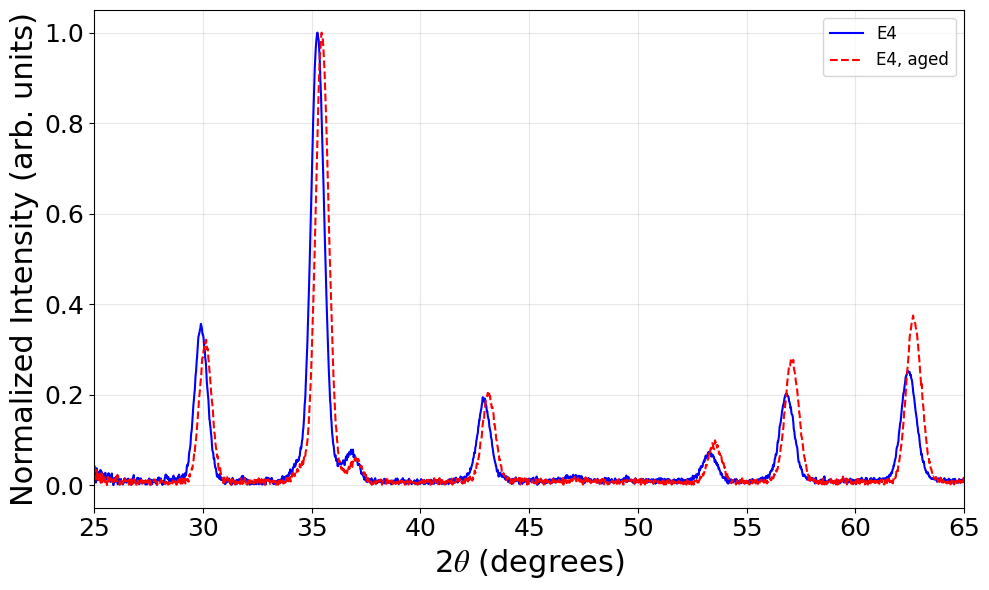

In [7]:
import os
import matplotlib as mpl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["mathtext.fontset"] = "stix" 

# USER INPUTS

# File location
data_dir = r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names"
 
# Only the two files to overlay
file_list = [
    #"E3_XRD_bg_sub.csv",
    "E4_XRD_bg_sub.csv",
    #"E1_XRD_bg_sub.csv",
    #"E3_XRD_aged_spot2_20520s_bg_sub.csv",
    #"E5_XRD_bg_sub.csv",
    #"E5_260413_bg_sub_20520.csv",
    "E4_remeasured_260519_bg_sub.csv",

]

# Labels for legend
plot_labels = [
    #"20520 s",
    #"20520 s, aged",
    "E4",
    "E4, aged",
]

# Colors
color_list = [
    "blue",
    "red",
]

# Line styles
linestyle_list = [
    "solid",
    "dashed",
]

x_col = "two_theta"
y_col = "intensity"

# Plot styling
x_label = r"2$\theta$ (degrees)"
y_label = "Normalized Intensity (arb. units)"
title = "XRD Comparison"

font_size_axes_labels = 22
font_size_ticks = 18
font_size_title = 16
line_width = 1.5

# x-limits
x_min = 25
x_max = 65

save_fig = False
output_filename = "E5_20520_overlay_cropped_minmax.png"
output_dpi = 600

# LOAD, CROP, NORMALIZE, PLOT

fig, ax = plt.subplots(figsize=(10, 6))

for i, fname in enumerate(file_list):
    fpath = os.path.join(data_dir, fname)

    df = pd.read_csv(
        fpath,
        header=None,
        names=[x_col, y_col]
    )

    # extract x (2θ) and y (intensity)
    x = df[x_col].to_numpy()
    y = df[y_col].to_numpy()

    # crop first between x_min and x_max
    mask = (x >= x_min) & (x <= x_max)
    x_crop = x[mask]
    y_crop = y[mask]

    # min-max normalize cropped data
    y_min = np.min(y_crop)
    y_max = np.max(y_crop)

    if y_max - y_min == 0:
        y_norm = np.zeros_like(y_crop)
    else:
        y_norm = (y_crop - y_min) / (y_max - y_min)

    ax.plot(
        x_crop,
        y_norm,
        linewidth=line_width,
        label=plot_labels[i],
        color=color_list[i],
        linestyle=linestyle_list[i],
    )

# axis labels and ticks
ax.set_xlabel(x_label, fontsize=font_size_axes_labels)
ax.set_ylabel(y_label, fontsize=font_size_axes_labels)
# ax.set_title(title, fontsize=font_size_title)

ax.tick_params(axis='both', which='both', labelsize=font_size_ticks)

# x-limits
ax.set_xlim([x_min, x_max])

# legend
ax.legend(fontsize=12)

# transparent background
ax.set_facecolor("none")
fig.patch.set_alpha(0.0)

plt.tight_layout()
plt.grid(True, alpha=0.3)

# save figure
if save_fig:
    fig.savefig(
        output_filename,
        dpi=output_dpi,
        transparent=True
    )

plt.show()

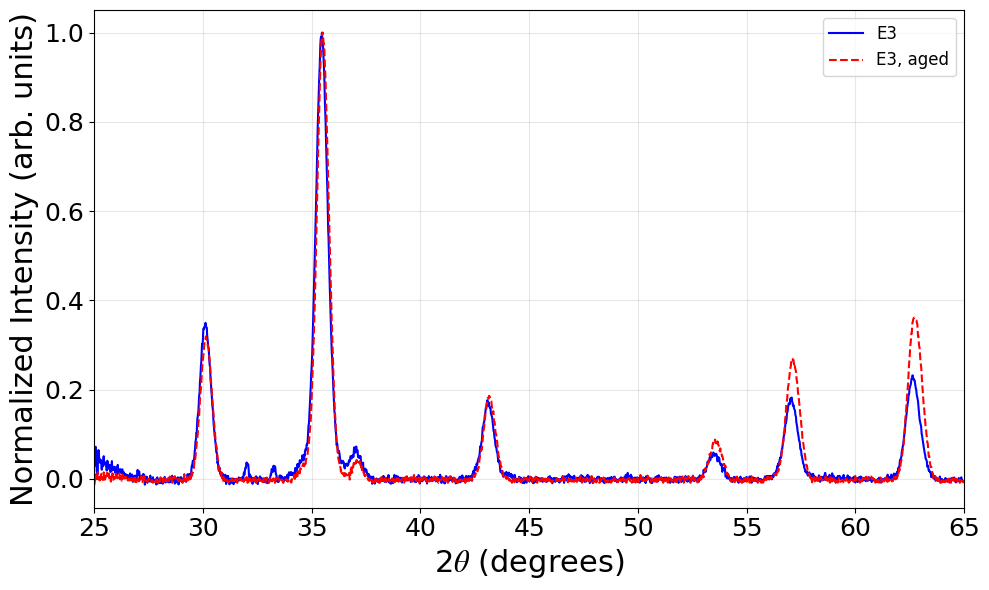

In [25]:
import os
import matplotlib as mpl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["mathtext.fontset"] = "stix" 

# USER INPUTS

# File location
data_dir = r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names"
 
# Only the two files to overlay
file_list = [
    "E3_XRD_bg_sub.csv",
    #"E4_XRD_bg_sub.csv",
    #"E1_XRD_bg_sub.csv",
    "E3_XRD_aged_spot2_20520s_bg_sub.csv",
    #"E5_XRD_bg_sub.csv",
    #"E5_260413_bg_sub_20520.csv",
    #"E4_remeasured_260519_bg_sub.csv",
]

# Labels for legend
plot_labels = [
    #"20520 s",
    #"20520 s, aged",
    "E3",
    "E3, aged",
]

# Colors
color_list = [
    "blue",
    "red",
]

# Line styles
linestyle_list = [
    "solid",
    "dashed",
]

x_col = "two_theta"
y_col = "intensity"

# Plot styling
x_label = r"2$\theta$ (degrees)"
y_label = "Normalized Intensity (arb. units)"
title = "XRD Comparison"

font_size_axes_labels = 22
font_size_ticks = 18
font_size_title = 16
line_width = 1.5

# x-limits
x_min = 25
x_max = 65

save_fig = False
output_filename = "E5_20520_overlay_cropped_maxnorm.png"
output_dpi = 600

# LOAD, CROP, NORMALIZE, PLOT

fig, ax = plt.subplots(figsize=(10, 6))

for i, fname in enumerate(file_list):
    fpath = os.path.join(data_dir, fname)

    df = pd.read_csv(
        fpath,
        header=None,
        names=[x_col, y_col]
    )

    # extract x (2θ) and y (intensity)
    x = df[x_col].to_numpy()
    y = df[y_col].to_numpy()

    # crop first between x_min and x_max
    mask = (x >= x_min) & (x <= x_max)
    x_crop = x[mask]
    y_crop = y[mask]

    # max normalize cropped data
    y_max = np.max(y_crop)

    if y_max == 0:
        y_norm = np.zeros_like(y_crop)
    else:
        y_norm = y_crop / y_max

    ax.plot(
        x_crop,
        y_norm,
        linewidth=line_width,
        label=plot_labels[i],
        color=color_list[i],
        linestyle=linestyle_list[i],
    )

# axis labels and ticks
ax.set_xlabel(x_label, fontsize=font_size_axes_labels)
ax.set_ylabel(y_label, fontsize=font_size_axes_labels)
# ax.set_title(title, fontsize=font_size_title)

ax.tick_params(axis='both', which='both', labelsize=font_size_ticks)

# x-limits
ax.set_xlim([x_min, x_max])

# legend
ax.legend(fontsize=12)

# transparent background
ax.set_facecolor("none")
fig.patch.set_alpha(0.0)

plt.tight_layout()
plt.grid(True, alpha=0.3)

# save figure
if save_fig:
    fig.savefig(
        output_filename,
        dpi=output_dpi,
        transparent=True
    )

plt.show()

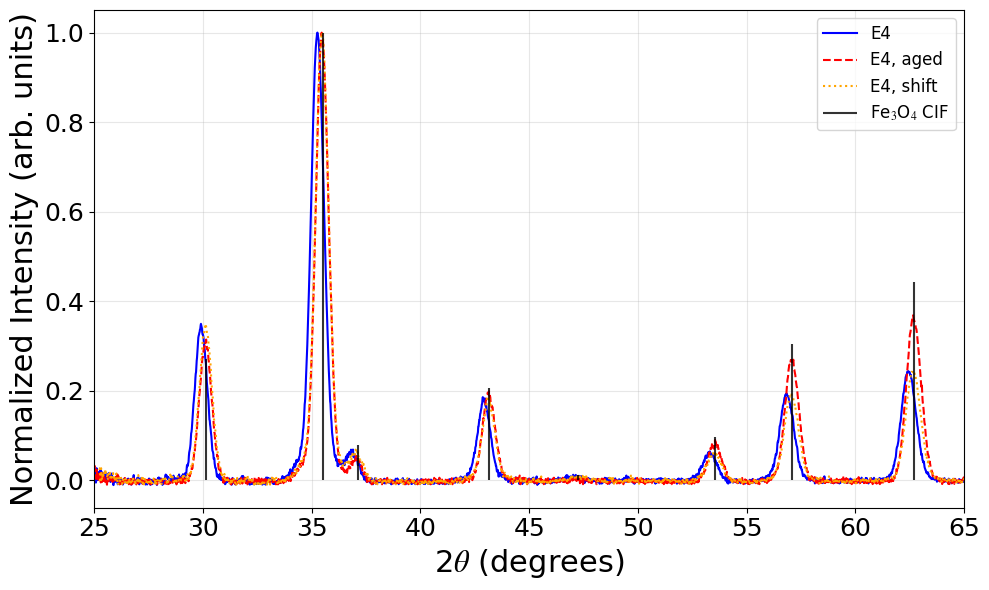

In [22]:
import os
import matplotlib as mpl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator

mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["mathtext.fontset"] = "stix" 

# USER INPUTS

# File location
data_dir = r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names"

# CIF location
cif_dir = r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model"
cif_filename = "1010369_Fe3O4.cif"
cif_path = os.path.join(cif_dir, cif_filename)

# Only the two files to overlay
file_list = [
    #"E3_XRD_bg_sub.csv",
    "E4_XRD_bg_sub.csv",
    #"E1_XRD_bg_sub.csv",
    #"E3_XRD_aged_spot2_20520s_bg_sub.csv",
    #"E5_XRD_bg_sub.csv",
    #"E5_260413_bg_sub_20520.csv",
    "E4_remeasured_260519_bg_sub.csv",
    "E4_XRD_bg_sub_raw_2theta_shift_p0p210deg.csv",
]

# Labels for legend
plot_labels = [
    #"20520 s",
    #"20520 s, aged",
    "E4",
    "E4, aged",
    "E4, shift"
]

# Colors
color_list = [
    "blue",
    "red",
    "orange"
]

# Line styles
linestyle_list = [
    "solid",
    "dashed",
    "dotted",
]

# CIF stick-pattern style
stick_label = "Fe$_3$O$_4$ CIF"
stick_color = "black"
stick_linewidth = 1.5
stick_alpha = 0.8

x_col = "two_theta"
y_col = "intensity"

# Plot styling
x_label = r"2$\theta$ (degrees)"
y_label = "Normalized Intensity (arb. units)"
title = "XRD Comparison"

font_size_axes_labels = 22
font_size_ticks = 18
font_size_title = 16
line_width = 1.5

# x-limits
x_min = 25
x_max = 65

save_fig = False
output_filename = "E4_overlay_with_CIF_stick_pattern_maxnorm.png"
output_dpi = 600

# LOAD, CROP, NORMALIZE, PLOT

fig, ax = plt.subplots(figsize=(10, 6))

for i, fname in enumerate(file_list):
    fpath = os.path.join(data_dir, fname)

    df = pd.read_csv(
        fpath,
        header=None,
        names=[x_col, y_col]
    )

    # extract x (2θ) and y (intensity)
    x = df[x_col].to_numpy()
    y = df[y_col].to_numpy()

    # crop first between x_min and x_max
    mask = (x >= x_min) & (x <= x_max)
    x_crop = x[mask]
    y_crop = y[mask]

    # max normalize cropped data
    y_max = np.max(y_crop)

    if y_max == 0:
        y_norm = np.zeros_like(y_crop)
    else:
        y_norm = y_crop / y_max

    ax.plot(
        x_crop,
        y_norm,
        linewidth=line_width,
        label=plot_labels[i],
        color=color_list[i],
        linestyle=linestyle_list[i],
    )

# LOAD CIF AND PLOT MAX-NORMALIZED STICK PATTERN

structure = Structure.from_file(cif_path)

calc = XRDCalculator(wavelength="CuKa")
pattern = calc.get_pattern(
    structure,
    two_theta_range=(x_min, x_max)
)

stick_x = np.asarray(pattern.x)
stick_y = np.asarray(pattern.y)

# max normalize CIF stick intensities
if stick_y.max() == 0:
    stick_y_norm = np.zeros_like(stick_y)
else:
    stick_y_norm = stick_y / stick_y.max()

ax.vlines(
    stick_x,
    ymin=0,
    ymax=stick_y_norm,
    colors=stick_color,
    linewidth=stick_linewidth,
    alpha=stick_alpha,
    label=stick_label
)

# axis labels and ticks
ax.set_xlabel(x_label, fontsize=font_size_axes_labels)
ax.set_ylabel(y_label, fontsize=font_size_axes_labels)
# ax.set_title(title, fontsize=font_size_title)

ax.tick_params(axis='both', which='both', labelsize=font_size_ticks)

# x-limits
ax.set_xlim([x_min, x_max])

# legend
ax.legend(fontsize=12)

# transparent background
ax.set_facecolor("none")
fig.patch.set_alpha(0.0)

plt.tight_layout()
plt.grid(True, alpha=0.3)

# save figure
if save_fig:
    fig.savefig(
        output_filename,
        dpi=output_dpi,
        transparent=True
    )

plt.show()

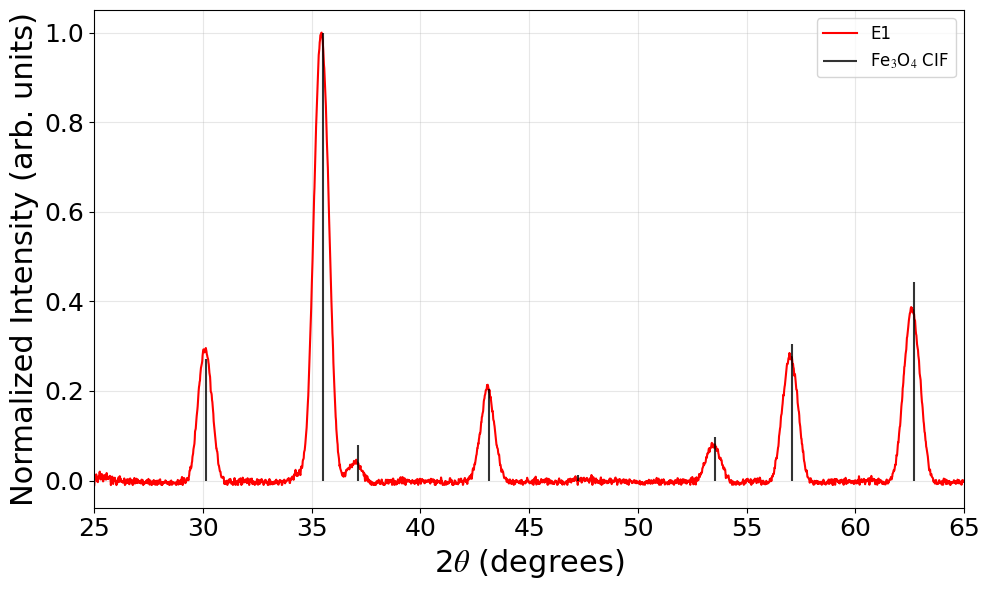

In [16]:
import os
import matplotlib as mpl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator

mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["mathtext.fontset"] = "stix" 

# USER INPUTS

# File location
data_dir = r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names"

# CIF location
cif_dir = r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model"
cif_filename = "1010369_Fe3O4.cif"
cif_path = os.path.join(cif_dir, cif_filename)

# Only the two files to overlay
file_list = [
    #"E3_XRD_bg_sub.csv",
    #"E4_XRD_bg_sub.csv",
    "E1_XRD_bg_sub.csv",
    #"E2_XRD_bg_sub.csv",
    #"E3_XRD_aged_spot2_20520s_bg_sub.csv",
    #"E5_XRD_bg_sub.csv",
    #"E5_260413_bg_sub_20520.csv",
    #"E4_remeasured_260519_bg_sub.csv",
    #"E4_XRD_bg_sub_raw_2theta_shift_p0p210deg.csv",
]

# Labels for legend
plot_labels = [
    #"20520 s",
    #"20520 s, aged",
    #"E4",
    #"E4, aged",
    #"E4, shift"
    "E1",
    #"E2",
    #"E3, aged",
]

# Colors
color_list = [
    #"blue",
    "red",
    #"orange"
]

# Line styles
linestyle_list = [
    "solid",
    "dashed",
    "dotted",
]

# CIF stick-pattern style
stick_label = "Fe$_3$O$_4$ CIF"
stick_color = "black"
stick_linewidth = 1.5
stick_alpha = 0.8

x_col = "two_theta"
y_col = "intensity"

# Plot styling
x_label = r"2$\theta$ (degrees)"
y_label = "Normalized Intensity (arb. units)"
title = "XRD Comparison"

font_size_axes_labels = 22
font_size_ticks = 18
font_size_title = 16
line_width = 1.5

# x-limits
x_min = 25
x_max = 65

save_fig = False
output_filename = "E4_overlay_with_CIF_stick_pattern_maxnorm.png"
output_dpi = 600

# LOAD, CROP, NORMALIZE, PLOT

fig, ax = plt.subplots(figsize=(10, 6))

for i, fname in enumerate(file_list):
    fpath = os.path.join(data_dir, fname)

    df = pd.read_csv(
        fpath,
        header=None,
        names=[x_col, y_col]
    )

    # extract x (2θ) and y (intensity)
    x = df[x_col].to_numpy()
    y = df[y_col].to_numpy()

    # crop first between x_min and x_max
    mask = (x >= x_min) & (x <= x_max)
    x_crop = x[mask]
    y_crop = y[mask]

    # max normalize cropped data
    y_max = np.max(y_crop)

    if y_max == 0:
        y_norm = np.zeros_like(y_crop)
    else:
        y_norm = y_crop / y_max

    ax.plot(
        x_crop,
        y_norm,
        linewidth=line_width,
        label=plot_labels[i],
        color=color_list[i],
        linestyle=linestyle_list[i],
    )

# LOAD CIF AND PLOT MAX-NORMALIZED STICK PATTERN

structure = Structure.from_file(cif_path)

calc = XRDCalculator(wavelength="CuKa")
pattern = calc.get_pattern(
    structure,
    two_theta_range=(x_min, x_max)
)

stick_x = np.asarray(pattern.x)
stick_y = np.asarray(pattern.y)

# max normalize CIF stick intensities
if stick_y.max() == 0:
    stick_y_norm = np.zeros_like(stick_y)
else:
    stick_y_norm = stick_y / stick_y.max()

ax.vlines(
    stick_x,
    ymin=0,
    ymax=stick_y_norm,
    colors=stick_color,
    linewidth=stick_linewidth,
    alpha=stick_alpha,
    label=stick_label
)

# axis labels and ticks
ax.set_xlabel(x_label, fontsize=font_size_axes_labels)
ax.set_ylabel(y_label, fontsize=font_size_axes_labels)
# ax.set_title(title, fontsize=font_size_title)

ax.tick_params(axis='both', which='both', labelsize=font_size_ticks)

# x-limits
ax.set_xlim([x_min, x_max])

# legend
ax.legend(fontsize=12)

# transparent background
ax.set_facecolor("none")
fig.patch.set_alpha(0.0)

plt.tight_layout()
plt.grid(True, alpha=0.3)

# save figure
if save_fig:
    fig.savefig(
        output_filename,
        dpi=output_dpi,
        transparent=True
    )

plt.show()